In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from tqdm.auto import tqdm

In [3]:
from sklearn.model_selection import train_test_split

# ===== 正確資料路徑 =====
data_root = Path("/kaggle/input/datasets/prashant268/chest-xray-covid19-pneumonia/Data")
out_dir = Path("/kaggle/working/splits")
out_dir.mkdir(parents=True, exist_ok=True)

classes = ["COVID19", "NORMAL", "PNEUMONIA"]
valid_exts = {".png", ".jpg", ".jpeg"}

records_train = []
records_test = []
all_files = []

# ===== 收集所有圖片 =====
for split in ["train", "test"]:
    for cls in classes:
        folder = data_root / split / cls
        files = [f for f in folder.iterdir() if f.suffix.lower() in valid_exts]
        print(f"{split}/{cls}: {len(files)} images")

        for f in files:
            all_files.append((split, cls, f))

print("\nTotal images:", len(all_files))

# ===== 單一進度條 =====
for split, cls, f in tqdm(all_files, desc="Scanning dataset", unit="img"):

    row = {
        "image_path": str(f),
        "label": cls
    }

    if split == "train":
        records_train.append(row)
    else:
        records_test.append(row)

train_full_df = pd.DataFrame(records_train)
test_df = pd.DataFrame(records_test)

# ===== train -> train + val =====
train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.2,
    stratify=train_full_df["label"],
    random_state=42
)

# reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ===== 存檔 =====
train_df.to_csv(out_dir / "train.csv", index=False)
val_df.to_csv(out_dir / "val.csv", index=False)
test_df.to_csv(out_dir / "test.csv", index=False)

# ===== summary =====
print("\nTrain distribution")
print(train_df["label"].value_counts())

print("\nVal distribution")
print(val_df["label"].value_counts())

print("\nTest distribution")
print(test_df["label"].value_counts())

print("\nSaved to:", out_dir)

train/COVID19: 460 images
train/NORMAL: 1266 images
train/PNEUMONIA: 3418 images
test/COVID19: 116 images
test/NORMAL: 317 images
test/PNEUMONIA: 855 images

Total images: 6432


Scanning dataset:   0%|          | 0/6432 [00:00<?, ?img/s]


Train distribution
label
PNEUMONIA    2734
NORMAL       1013
COVID19       368
Name: count, dtype: int64

Val distribution
label
PNEUMONIA    684
NORMAL       253
COVID19       92
Name: count, dtype: int64

Test distribution
label
PNEUMONIA    855
NORMAL       317
COVID19      116
Name: count, dtype: int64

Saved to: /kaggle/working/splits


設定整個實驗要用的參數與環境

In [7]:
# ===== 路徑 =====
split_dir = Path("/kaggle/working/splits")
work_dir = Path("/kaggle/working/baseline_resnet18")
work_dir.mkdir(parents=True, exist_ok=True)

train_csv = split_dir / "train.csv"
val_csv = split_dir / "val.csv"
test_csv = split_dir / "test.csv"

# ===== 類別設定 =====
class_names = ["COVID19", "NORMAL", "PNEUMONIA"]
class_to_idx = {name: i for i, name in enumerate(class_names)}

# ===== 訓練參數 =====
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4
SEED = 42
NUM_WORKERS = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===== 固定隨機種子 =====
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Using device: cuda


In [8]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain distribution:")
print(train_df["label"].value_counts())


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label_name = row["label"]

        image = Image.open(img_path).convert("RGB")
        label = class_to_idx[label_name]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=eval_transform)
test_dataset = ChestXrayDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("\nDataLoaders ready.")

Train size: 4115
Val size: 1029
Test size: 1288

Train distribution:
label
PNEUMONIA    2734
NORMAL       1013
COVID19       368
Name: count, dtype: int64

DataLoaders ready.


!!!!!!!!!baseline

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 162MB/s] 


Linear(in_features=512, out_features=3, bias=True)


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total += batch_size

        progress_bar.set_postfix(
            loss=f"{running_loss/total:.4f}",
            acc=f"{running_corrects/total:.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=False)
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{running_loss/total:.4f}",
                acc=f"{running_corrects/total:.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=torch.cuda.is_available())

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=torch.cuda.is_available())

In [13]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, desc="Validation")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), work_dir / "best_resnet18_baseline.pt")
        print("Best model saved.")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")
print(f"Best Val Acc: {best_val_acc:.4f}")


Epoch [1/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.2176 | Train Acc: 0.9249
Val   Loss: 0.1335 | Val   Acc: 0.9582
Best model saved.

Epoch [2/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0442 | Train Acc: 0.9847
Val   Loss: 0.0559 | Val   Acc: 0.9767

Epoch [8/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0454 | Train Acc: 0.9842
Val   Loss: 0.0972 | Val   Acc: 0.9708

Training complete in 16.09 minutes
Best Val Acc: 0.9806


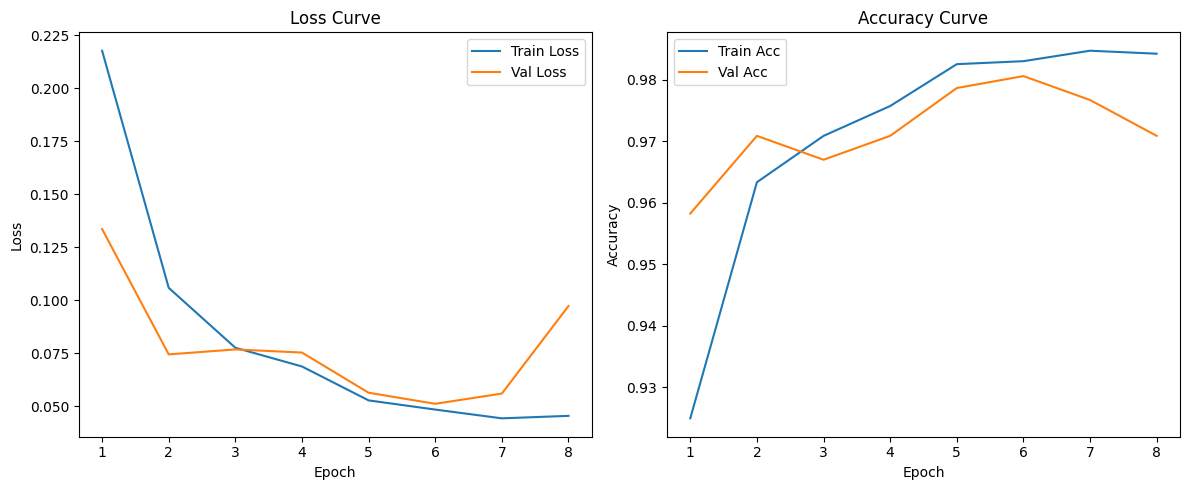

In [14]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
model.load_state_dict(torch.load(work_dir / "best_resnet18_baseline.pt", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(
    model, test_loader, criterion, device, desc="Testing"
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Testing:   0%|          | 0/41 [00:00<?, ?it/s]


Test Loss: 0.0973
Test Acc : 0.9697


Classification Report:

              precision    recall  f1-score   support

     COVID19     1.0000    0.9914    0.9957       116
      NORMAL     0.9346    0.9464    0.9404       317
   PNEUMONIA     0.9789    0.9754    0.9772       855

    accuracy                         0.9697      1288
   macro avg     0.9712    0.9711    0.9711      1288
weighted avg     0.9699    0.9697    0.9698      1288



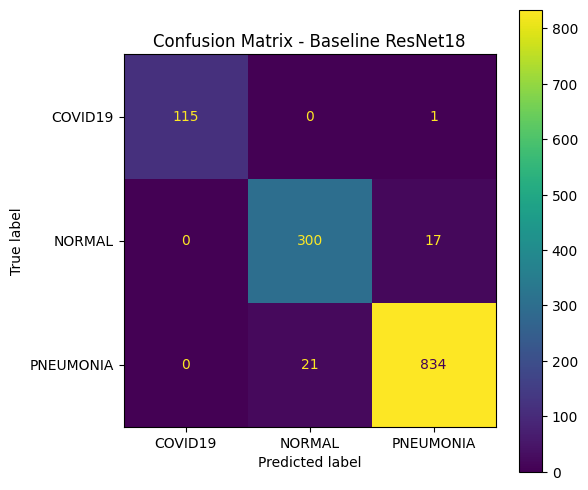

In [16]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Baseline ResNet18")
plt.show()

In [17]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

pred_df = test_df.copy()
pred_df["true_idx"] = y_true
pred_df["pred_idx"] = y_pred
pred_df["true_label"] = [idx_to_class[i] for i in y_true]
pred_df["pred_label"] = [idx_to_class[i] for i in y_pred]
pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_path = work_dir / "baseline_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions to:", pred_path)
pred_df.head()

Saved predictions to: /kaggle/working/baseline_resnet18/baseline_test_predictions.csv


,image_path,label,true_idx,pred_idx,true_label,pred_label,correct
0,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
1,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
2,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
3,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
4,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True


!!!!!!!!!class weight


In [18]:
train_counts = train_df["label"].value_counts()
print(train_counts)
import torch

counts = torch.tensor([
    train_counts["COVID19"],
    train_counts["NORMAL"],
    train_counts["PNEUMONIA"]
], dtype=torch.float)

class_weights = counts.sum() / (len(counts) * counts)
class_weights = class_weights.to(device)

print("Class weights:", class_weights)

label
PNEUMONIA    2734
NORMAL       1013
COVID19       368
Name: count, dtype: int64
Class weights: tensor([3.7274, 1.3541, 0.5017], device='cuda:0')


criterion 改成 weighted

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR)

print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total += batch_size

        progress_bar.set_postfix(
            loss=f"{running_loss/total:.4f}",
            acc=f"{running_corrects/total:.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=False)
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{running_loss/total:.4f}",
                acc=f"{running_corrects/total:.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [21]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

work_dir = Path("/kaggle/working/exp_class_weight")
work_dir.mkdir(exist_ok=True)

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, desc="Validation")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), work_dir / "best_resnet18_class_weight.pt")
        print("Best model saved.")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")
print(f"Best Val Acc: {best_val_acc:.4f}")


Epoch [1/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1990 | Train Acc: 0.9028
Val   Loss: 0.0613 | Val   Acc: 0.9747
Best model saved.

Epoch [2/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0382 | Train Acc: 0.9796
Val   Loss: 0.0544 | Val   Acc: 0.9796

Epoch [8/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0423 | Train Acc: 0.9801
Val   Loss: 0.1404 | Val   Acc: 0.9640

Training complete in 15.44 minutes
Best Val Acc: 0.9845


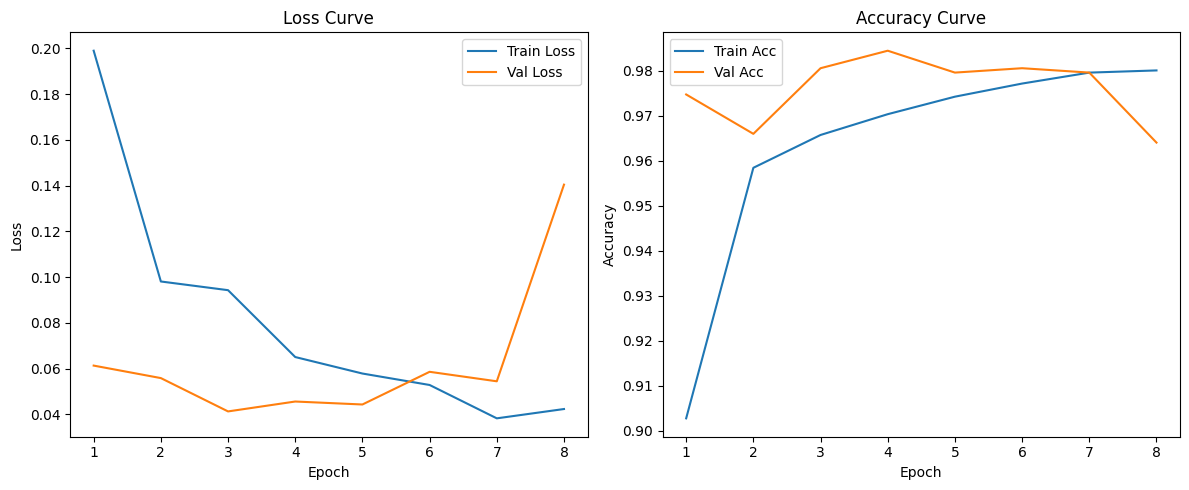

In [22]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
model.load_state_dict(torch.load(work_dir / "best_resnet18_class_weight.pt", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(
    model, test_loader, criterion, device, desc="Testing"
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Testing:   0%|          | 0/41 [00:00<?, ?it/s]


Test Loss: 0.0918
Test Acc : 0.9697


Classification Report:

              precision    recall  f1-score   support

     COVID19     1.0000    1.0000    1.0000       116
      NORMAL     0.9399    0.9369    0.9384       317
   PNEUMONIA     0.9766    0.9778    0.9772       855

    accuracy                         0.9697      1288
   macro avg     0.9722    0.9716    0.9719      1288
weighted avg     0.9697    0.9697    0.9697      1288



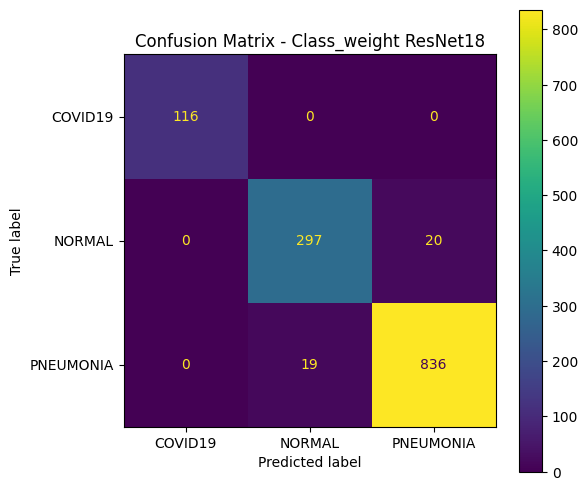

In [24]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Class_weight ResNet18")
plt.show()

In [25]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

pred_df = test_df.copy()
pred_df["true_idx"] = y_true
pred_df["pred_idx"] = y_pred
pred_df["true_label"] = [idx_to_class[i] for i in y_true]
pred_df["pred_label"] = [idx_to_class[i] for i in y_pred]
pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_path = work_dir / "class_weight_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions to:", pred_path)
pred_df.head()

Saved predictions to: /kaggle/working/exp_class_weight/class_weight_test_predictions.csv


,image_path,label,true_idx,pred_idx,true_label,pred_label,correct
0,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
1,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
2,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
3,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
4,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True


!!!!!!!!!!weighted sample

In [26]:
work_dir = Path("/kaggle/working/exp_sampler")
work_dir.mkdir(exist_ok=True)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [27]:
train_counts = train_df["label"].value_counts()
print(train_counts)

class_sample_counts = np.array([
    train_counts["COVID19"],
    train_counts["NORMAL"],
    train_counts["PNEUMONIA"]
])

class_weights = 1.0 / class_sample_counts
print("Class sample weights:", class_weights)

sample_weights = train_df["label"].map({
    "COVID19": class_weights[0],
    "NORMAL": class_weights[1],
    "PNEUMONIA": class_weights[2]
}).values

from torch.utils.data import WeightedRandomSampler

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

label
PNEUMONIA    2734
NORMAL       1013
COVID19       368
Name: count, dtype: int64
Class sample weights: [0.00271739 0.00098717 0.00036576]


In [28]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total += batch_size

        progress_bar.set_postfix(
            loss=f"{running_loss/total:.4f}",
            acc=f"{running_corrects/total:.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=False)
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{running_loss/total:.4f}",
                acc=f"{running_corrects/total:.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [29]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, desc="Validation")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), work_dir / "best_resnet18_sampler.pt")
        print("Best model saved.")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")
print(f"Best Val Acc: {best_val_acc:.4f}")


Epoch [1/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.1614 | Train Acc: 0.9431
Val   Loss: 0.0623 | Val   Acc: 0.9728
Best model saved.

Epoch [2/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0382 | Train Acc: 0.9864
Val   Loss: 0.0494 | Val   Acc: 0.9835
Best model saved.

Epoch [8/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0319 | Train Acc: 0.9871
Val   Loss: 0.0607 | Val   Acc: 0.9796

Training complete in 19.52 minutes
Best Val Acc: 0.9835


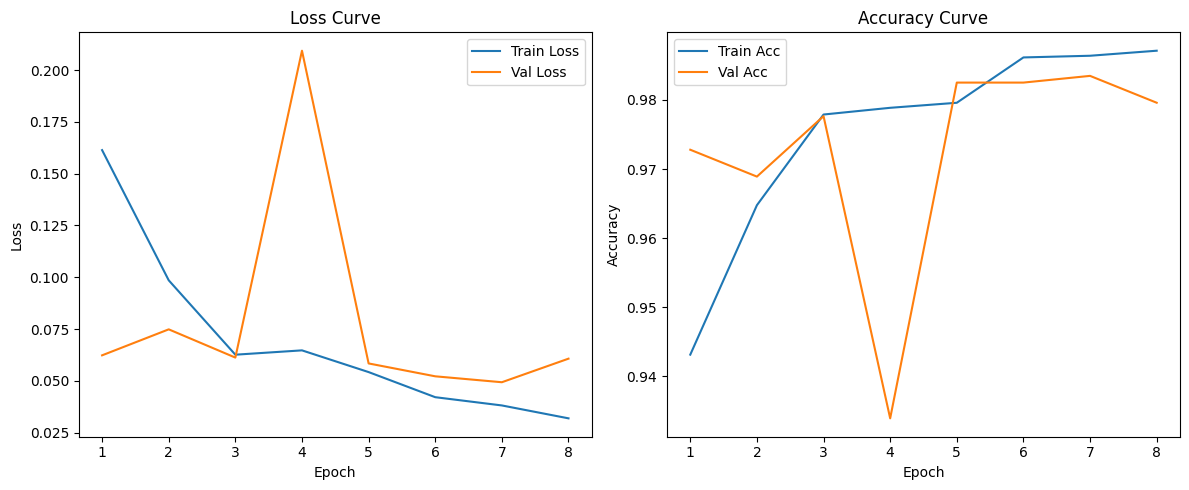

In [30]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
model.load_state_dict(torch.load(work_dir / "best_resnet18_sampler.pt", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(
    model, test_loader, criterion, device, desc="Testing"
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Testing:   0%|          | 0/41 [00:00<?, ?it/s]


Test Loss: 0.1145
Test Acc : 0.9682


Classification Report:

              precision    recall  f1-score   support

     COVID19     0.9914    0.9914    0.9914       116
      NORMAL     0.9315    0.9432    0.9373       317
   PNEUMONIA     0.9788    0.9743    0.9766       855

    accuracy                         0.9682      1288
   macro avg     0.9672    0.9696    0.9684      1288
weighted avg     0.9683    0.9682    0.9682      1288



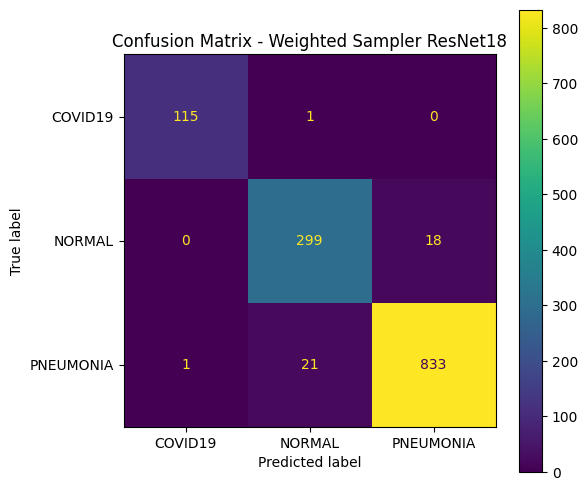

In [32]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Weighted Sampler ResNet18")
plt.show()

In [33]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

pred_df = test_df.copy()
pred_df["true_idx"] = y_true
pred_df["pred_idx"] = y_pred
pred_df["true_label"] = [idx_to_class[i] for i in y_true]
pred_df["pred_label"] = [idx_to_class[i] for i in y_pred]
pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_path = work_dir / "sampler_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions to:", pred_path)
pred_df.head()

Saved predictions to: /kaggle/working/exp_sampler/sampler_test_predictions.csv


,image_path,label,true_idx,pred_idx,true_label,pred_label,correct
0,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
1,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
2,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
3,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
4,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True


focal loss

In [35]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        return focal_loss.mean()

In [36]:
work_dir = Path("/kaggle/working/exp_focal")
work_dir.mkdir(exist_ok=True)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, len(class_names))
model = model.to(device)

criterion = FocalLoss(gamma=2)
optimizer = optim.Adam(model.parameters(), lr=LR)

print(model.fc)

Linear(in_features=512, out_features=3, bias=True)


In [37]:
# ===== DataLoader =====
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_corrects += torch.sum(preds == labels).item()
        total += batch_size

        progress_bar.set_postfix(
            loss=f"{running_loss/total:.4f}",
            acc=f"{running_corrects/total:.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device, desc="Evaluating"):
    model.eval()

    running_loss = 0.0
    running_corrects = 0
    total = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        progress_bar = tqdm(loader, desc=desc, leave=False)
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_corrects += torch.sum(preds == labels).item()
            total += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            progress_bar.set_postfix(
                loss=f"{running_loss/total:.4f}",
                acc=f"{running_corrects/total:.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, all_labels, all_preds

In [39]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc = 0.0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device, desc="Validation")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), work_dir / "best_resnet18_focal.pt")
        print("Best model saved.")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.2f} minutes")
print(f"Best Val Acc: {best_val_acc:.4f}")


Epoch [1/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0891 | Train Acc: 0.9091
Val   Loss: 0.0295 | Val   Acc: 0.9621
Best model saved.

Epoch [2/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0149 | Train Acc: 0.9823
Val   Loss: 0.0193 | Val   Acc: 0.9728

Epoch [8/8]


Training:   0%|          | 0/129 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Train Loss: 0.0138 | Train Acc: 0.9810
Val   Loss: 0.0157 | Val   Acc: 0.9786
Best model saved.

Training complete in 17.17 minutes
Best Val Acc: 0.9786


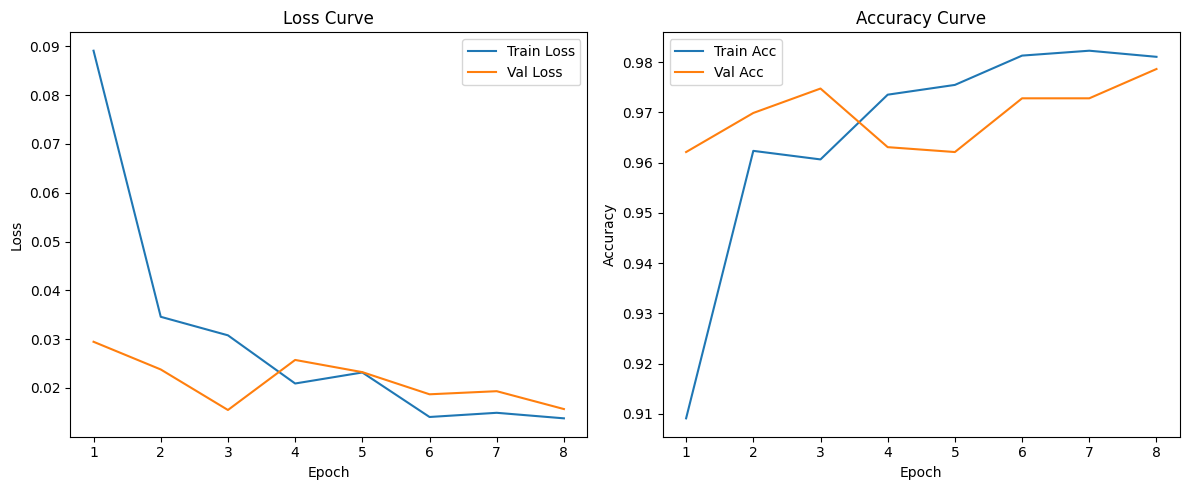

In [40]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [41]:
model.load_state_dict(torch.load(work_dir / "best_resnet18_focal.pt", map_location=device))

test_loss, test_acc, y_true, y_pred = evaluate(
    model, test_loader, criterion, device, desc="Testing"
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Testing:   0%|          | 0/41 [00:00<?, ?it/s]


Test Loss: 0.0354
Test Acc : 0.9589


Classification Report:

              precision    recall  f1-score   support

     COVID19     1.0000    0.9741    0.9869       116
      NORMAL     0.9105    0.9306    0.9204       317
   PNEUMONIA     0.9718    0.9673    0.9695       855

    accuracy                         0.9589      1288
   macro avg     0.9608    0.9573    0.9590      1288
weighted avg     0.9592    0.9589    0.9590      1288



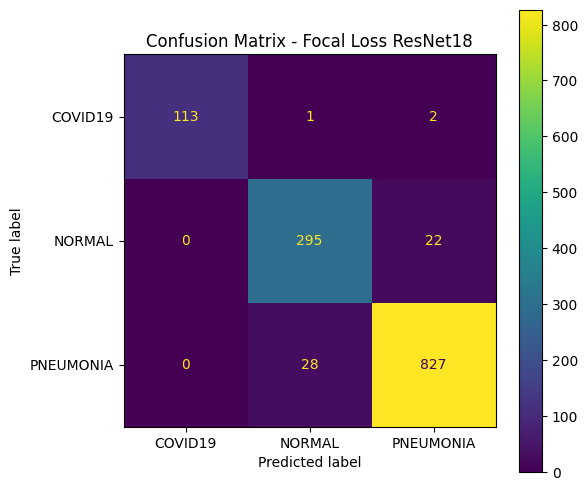

In [42]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Focal Loss ResNet18")
plt.show()

In [43]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

pred_df = test_df.copy()
pred_df["true_idx"] = y_true
pred_df["pred_idx"] = y_pred
pred_df["true_label"] = [idx_to_class[i] for i in y_true]
pred_df["pred_label"] = [idx_to_class[i] for i in y_pred]
pred_df["correct"] = pred_df["true_label"] == pred_df["pred_label"]

pred_path = work_dir / "focal_test_predictions.csv"
pred_df.to_csv(pred_path, index=False)

print("Saved predictions to:", pred_path)
pred_df.head()

Saved predictions to: /kaggle/working/exp_focal/focal_test_predictions.csv


,image_path,label,true_idx,pred_idx,true_label,pred_label,correct
0,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
1,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
2,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
3,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True
4,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,0,0,COVID19,COVID19,True


比較

In [44]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# ===== 1. 設定四組實驗 prediction CSV 路徑 =====
experiment_files = {
    "Baseline": Path("/kaggle/working/baseline_resnet18/baseline_test_predictions.csv"),
    "Class Weight": Path("/kaggle/working/exp_class_weight/class_weight_test_predictions.csv"),
    "Weighted Sampler": Path("/kaggle/working/exp_sampler/sampler_test_predictions.csv"),
    "Focal Loss": Path("/kaggle/working/exp_focal/focal_test_predictions.csv"),
}

# ===== 2. 計算每組指標 =====
results = []

for exp_name, csv_path in experiment_files.items():
    if not csv_path.exists():
        print(f"[Missing] {exp_name}: {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    y_true = df["true_label"]
    y_pred = df["pred_label"]

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    covid_precision = precision_score(y_true, y_pred, labels=["COVID19"], average="macro", zero_division=0)
    covid_recall = recall_score(y_true, y_pred, labels=["COVID19"], average="macro", zero_division=0)
    covid_f1 = f1_score(y_true, y_pred, labels=["COVID19"], average="macro", zero_division=0)

    results.append({
        "Experiment": exp_name,
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "COVID Precision": covid_precision,
        "COVID Recall": covid_recall,
        "COVID F1": covid_f1
    })

results_df = pd.DataFrame(results)

# 依 Macro F1 排序（你也可以改成 COVID Recall）
results_df = results_df.sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("=== Experiment Comparison Table ===")
display(results_df)

# 存檔
comparison_dir = Path("/kaggle/working/comparison")
comparison_dir.mkdir(exist_ok=True)

comparison_csv = comparison_dir / "experiment_comparison.csv"
results_df.to_csv(comparison_csv, index=False)

print(f"\nSaved comparison table to: {comparison_csv}")

=== Experiment Comparison Table ===


,Experiment,Accuracy,Macro F1,COVID Precision,COVID Recall,COVID F1
0,Class Weight,0.969720,0.971865,1.000000,1.000000,1.000000
1,Baseline,0.969720,0.971088,1.000000,0.991379,0.995671
2,Weighted Sampler,0.968168,0.968412,0.991379,0.991379,0.991379
3,Focal Loss,0.958851,0.958952,1.000000,0.974138,0.986900



Saved comparison table to: /kaggle/working/comparison/experiment_comparison.csv


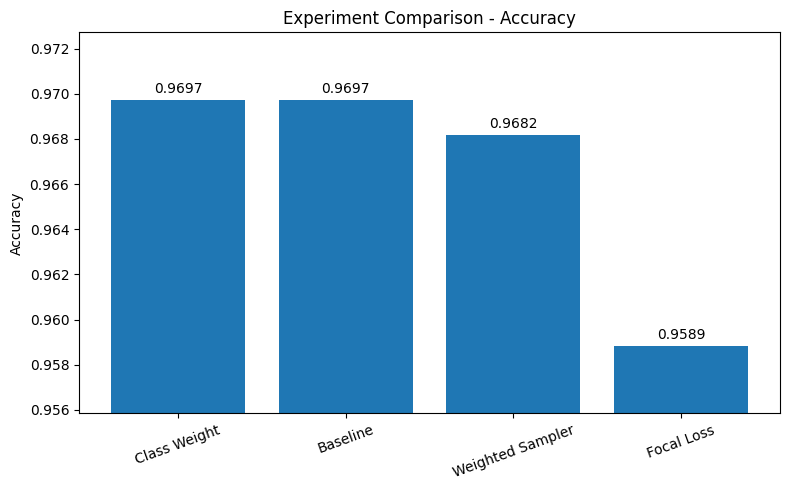

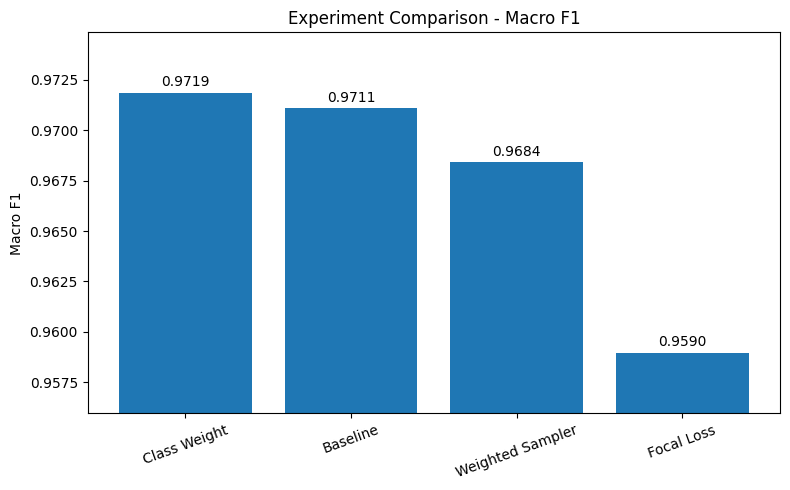

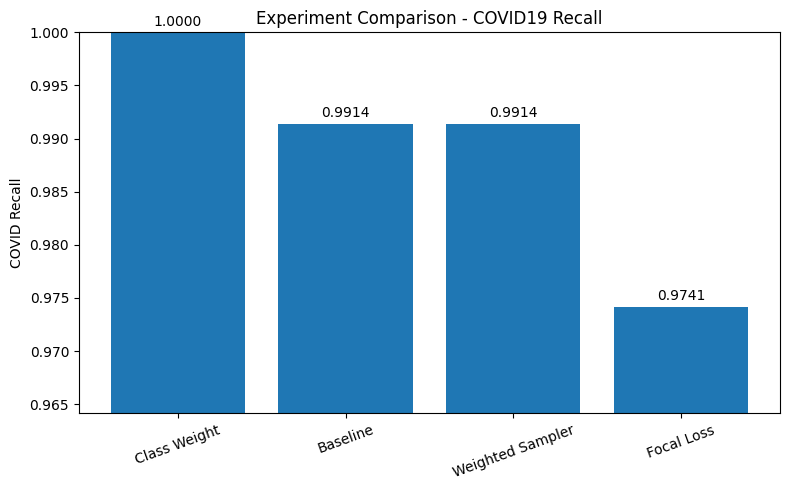

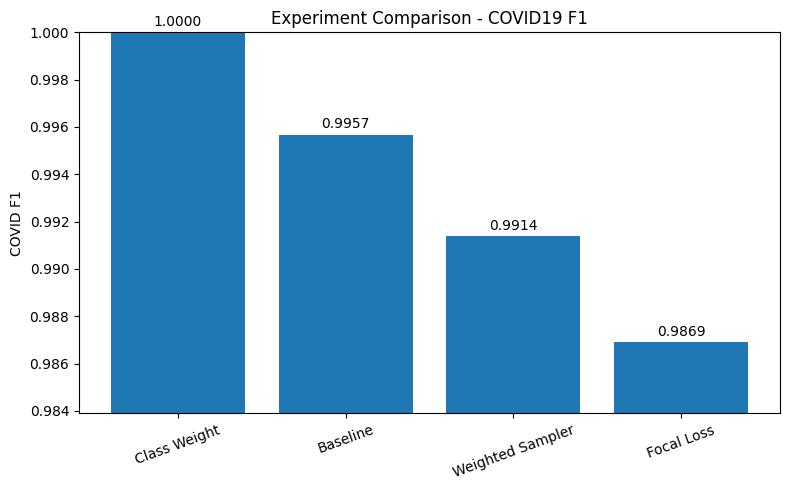

In [45]:
def plot_metric_bar(df, metric_col, title, ylabel=None, ylim_pad=0.003):
    x = np.arange(len(df))
    y = df[metric_col].values

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(df["Experiment"], y)

    # 讓 y 軸更細緻，放大差異
    y_min = y.min()
    y_max = y.max()
    lower = max(0, y_min - ylim_pad)
    upper = min(1.0, y_max + ylim_pad)
    ax.set_ylim(lower, upper)

    ax.set_title(title)
    ax.set_ylabel(ylabel if ylabel else metric_col)
    plt.xticks(rotation=20)

    # 在每根柱子上加數值
    for bar, val in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + (upper - lower) * 0.01,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()


# Accuracy
plot_metric_bar(
    results_df,
    metric_col="Accuracy",
    title="Experiment Comparison - Accuracy",
    ylabel="Accuracy",
    ylim_pad=0.003
)

# Macro F1
plot_metric_bar(
    results_df,
    metric_col="Macro F1",
    title="Experiment Comparison - Macro F1",
    ylabel="Macro F1",
    ylim_pad=0.003
)

# COVID Recall
plot_metric_bar(
    results_df,
    metric_col="COVID Recall",
    title="Experiment Comparison - COVID19 Recall",
    ylabel="COVID Recall",
    ylim_pad=0.01
)

# COVID F1
plot_metric_bar(
    results_df,
    metric_col="COVID F1",
    title="Experiment Comparison - COVID19 F1",
    ylabel="COVID F1",
    ylim_pad=0.003
)

誤判分析

In [46]:
# 以最佳模型的 predictions csv 為例
# 例如 focal loss:
pred_df = pd.read_csv("/kaggle/working/exp_focal/focal_test_predictions.csv")

# 篩出誤判樣本
errors_df = pred_df[pred_df["correct"] == False].copy()

print("Number of misclassified samples:", len(errors_df))
display(errors_df[["image_path", "true_label", "pred_label"]].head(20))

# 另存成 csv
errors_path = "/kaggle/working/exp_focal/focal_misclassified_samples.csv"
errors_df.to_csv(errors_path, index=False)
print("Saved to:", errors_path)

Number of misclassified samples: 53


,image_path,true_label,pred_label
54,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,NORMAL
64,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,PNEUMONIA
110,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,PNEUMONIA
118,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
143,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
146,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
147,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
156,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
185,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
209,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA


Saved to: /kaggle/working/exp_focal/focal_misclassified_samples.csv


Number of misclassified samples: 53


,image_path,true_label,pred_label
0,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,NORMAL
1,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,PNEUMONIA
2,/kaggle/input/datasets/prashant268/chest-xray-...,COVID19,PNEUMONIA
3,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
4,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
5,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
6,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
7,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
8,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA
9,/kaggle/input/datasets/prashant268/chest-xray-...,NORMAL,PNEUMONIA


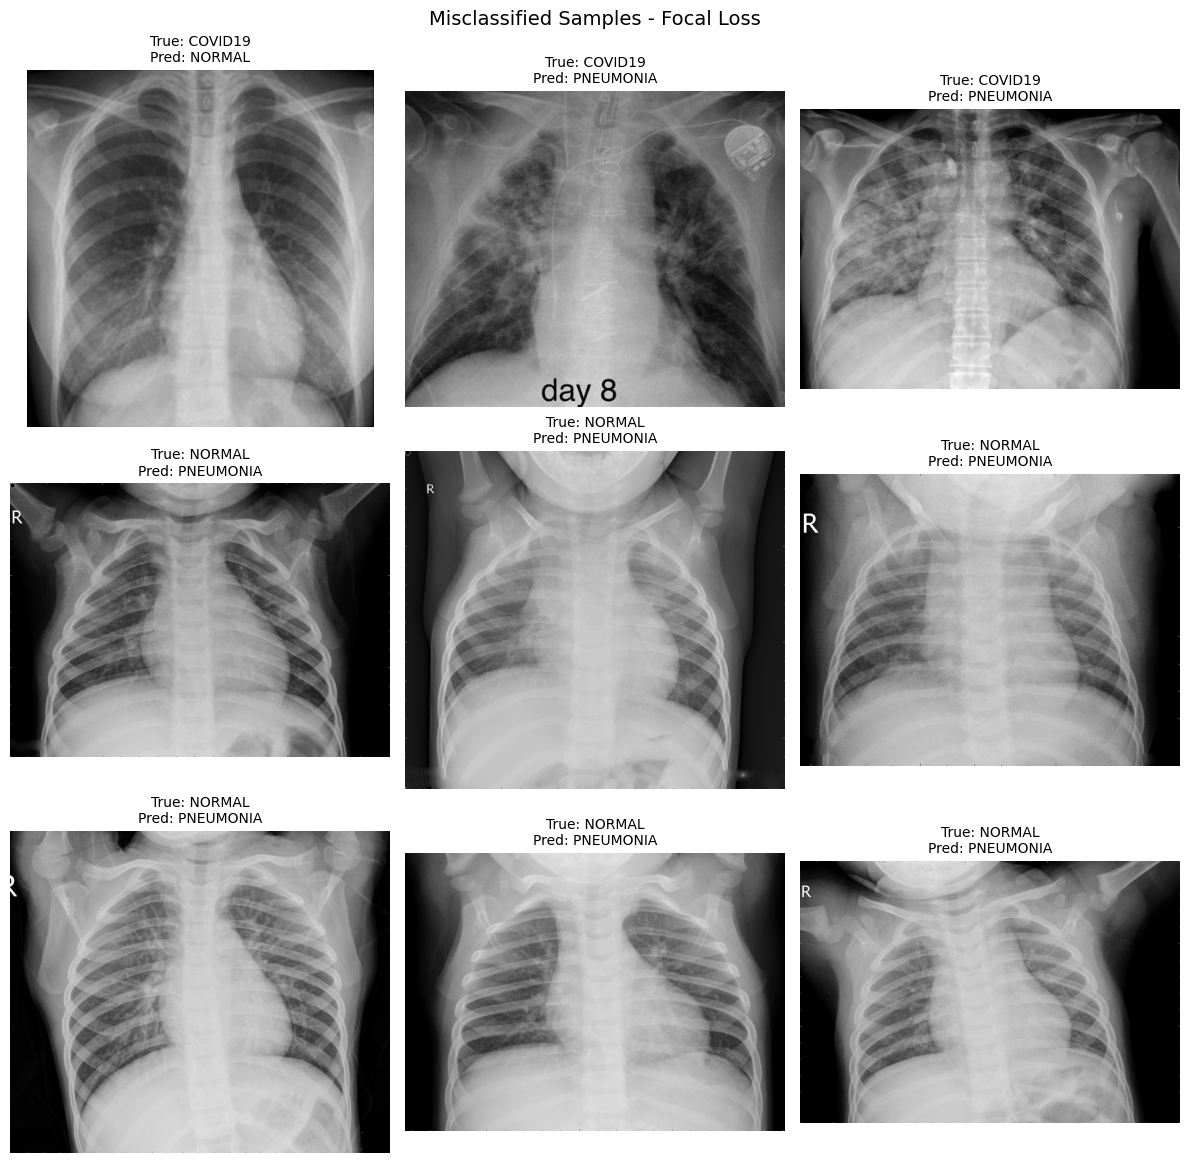

In [47]:
from PIL import Image
import math

# 讀最佳模型 predictions
pred_df = pd.read_csv("/kaggle/working/exp_focal/focal_test_predictions.csv")

# 篩出誤判樣本
errors_df = pred_df[pred_df["correct"] == False].copy().reset_index(drop=True)

print("Number of misclassified samples:", len(errors_df))
display(errors_df[["image_path", "true_label", "pred_label"]].head(10))

# 顯示前 9 張誤判圖
n_show = min(9, len(errors_df))
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    ax = axes[i]
    ax.axis("off")

    if i < n_show:
        row = errors_df.iloc[i]
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['pred_label']}",
            fontsize=10
        )

plt.suptitle("Misclassified Samples - Focal Loss", fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
error_summary = pd.crosstab(errors_df["true_label"], errors_df["pred_label"])
print(error_summary)

pred_label  NORMAL  PNEUMONIA
true_label                   
COVID19          1          2
NORMAL           0         22
PNEUMONIA       28          0
